# Trabajo 2 - Grupo 6  

**Curso:** INTRODUCCIÓN A CIENCIA DE DATOS Y MACHINE LEARNING CON PYTHON  
**Profesor:** Luis Zapata Bobadilla  

---

## Integrantes
- Carmen Crisanto, César Jair  
- Miranda Sanchez, Alex Abraham Patrick  
- Prado Chafloque, Sarai Elizabeth  
- Reategui Zapata, Joaquin Alejandro  

---

## Pregunta de investigación
**¿Cómo influye el déficit fiscal en las expectativas empresariales de corto plazo (3 meses) y largo plazo (12 meses)?**  



El análisis que llevamos a cabo se centra en la relación entre déficit fiscal y las expectativas empresariales, dos variables clave para entender la dinámica macroeconómica.

El déficit fiscal refleja la diferencia entre los gastos y los ingresos del gobierno, así, un déficit persistente puede tener efectos sobre la inflación, tasas de interés y la confianza empresarial, especialmente en economías emergentes como la nuestra donde el financiamiento del gasto público depende de factores externos o del mercado interno de deuda.

Por otro lado, tenemos a las expectativas empresariales, que son un indicador de la actividad económica: recogen cómo los empresarios perciben la situación actual y futura de la economía. Así, las expectativas influyen en la inversión y, en consecuencia, en el crecimiento económico. Por esto, en un entorno de incertidumbre fiscal se puede deteriorar la confianza y reducir la inversión privada.

Dicho esto, en este proyecto, exploramos cómo la evolución del déficit fiscal se relaciona con las expectativas empresariales, utilizando series temporales del Banco Central de Reserva del Perú (BCRP). Asimismo, se desarrollan modelos de regresión que permiten explorar cómo las variaciones en la política monetaria y fiscal se asocian con los cambios en las expectativas empresariales.


Antes de cualquier modelo, revisamos las columnas del Dataframe y verificamos la estructura de los datos.

In [ ]:
import requests, json, pandas as pd, numpy as np, re

series = [
    "PN39524FM",  # Déficit fiscal
    "PD38045AM",  # Expectativas economía 3m
    "PD37981AM",  # Expectativas economía 12m
    "PD04722MM",  # Tasa de referencia
    "PN02409FM",   # Gasto No Financiero Total
    "PN01129XM",  # EMBIG - Perú
]
inicio = "2015-01"
fin    = "2025-12"

codigos = "-".join(series)
url = f"https://estadisticas.bcrp.gob.pe/estadisticas/series/api/{codigos}/json/{inicio}/{fin}"
r = requests.get(url, timeout=30)
r.raise_for_status()

try:
    data = r.json()
except json.JSONDecodeError:
    data = json.loads(r.text.lstrip("\ufeff").strip())

MESES = {'Ene':'01','Feb':'02','Mar':'03','Abr':'04','May':'05','Jun':'06',
         'Jul':'07','Ago':'08','Sep':'09','Oct':'10','Nov':'11','Dic':'12'}
def parse_fecha(s):
    s = str(s).strip()
    m = re.match(r'^([A-Za-zÁÉÍÓÚÑáéíóúñ]{3})\.(\d{4})$', s)
    if m:
        mm = MESES.get(m.group(1).title())
        return pd.to_datetime(f"{m.group(2)}-{mm}-01", errors="coerce")
    return pd.to_datetime(s, errors="coerce", dayfirst=False)

def to_float(x):
    if x in (None, 'n.d.', 'NaN', ''):
        return np.nan
    try:
        return float(x)
    except Exception:
        return np.nan

if isinstance(data, dict) and 'periods' in data:

    meta_series = []
    cfg = data.get('config', {})
    if isinstance(cfg, dict) and isinstance(cfg.get('series'), list) and cfg['series']:

        if 'code' in cfg['series'][0]:
            meta_series = [s.get('code') for s in cfg['series']]
        else:

            meta_series = [s.get('name') for s in cfg['series']]
    if not meta_series:

        meta_series = series

    rows = []
    for per in data['periods']:
        fecha = parse_fecha(per.get('name'))
        vals = per.get('values', [])
        # normalizar longitud (pad/trunc)
        if len(vals) < len(meta_series):
            vals = vals + [None] * (len(meta_series) - len(vals))
        elif len(vals) > len(meta_series):
            vals = vals[:len(meta_series)]
        row = {'date': fecha}
        for col, v in zip(meta_series, vals):
            row[col] = to_float(v)
        rows.append(row)

    df = pd.DataFrame(rows).set_index('date').sort_index()

elif isinstance(data, dict) and 'series' in data:

    rows = {}
    for s in data['series']:
        code = s.get('code') or s.get('codigo') or s.get('name')
        for p in s.get('periods', []):
            fecha = parse_fecha(p.get('name'))
            val_list = p.get('values', [None])
            val = to_float(val_list[0] if isinstance(val_list, list) and val_list else val_list)
            rows.setdefault(fecha, {})[code] = val
    df = pd.DataFrame.from_dict(rows, orient='index').sort_index()

else:
    raise ValueError("Respuesta del API no reconocida (sin 'periods' ni 'series').")

# ===== Reindex mensual 2015-01..2025-12 y alias =====
idx = pd.date_range(start="2015-01-01", end="2025-12-01", freq="MS")
df = df.reindex(idx)
df.index.name = "date"

alias = {
    "PN39524FM":"deficit_fiscal",
    "PD38045AM":"exp_eco_3m",
    "PD37981AM":"exp_eco_12m",
    "PD04722MM":"tasa_ref",
    "PN2409FM":"gasto_no_financiero",
    "PN01129XM":"embig_pe"
}
# solo renombrar las columnas que existan
rename_map = {k:v for k,v in alias.items() if k in df.columns}
df = df.rename(columns=rename_map)

print("URL:", url)
print("Dimensiones:", df.shape)
print("Columnas:", list(df.columns))
print("Nulos por serie:\n", df.isna().sum())
display(df.head(10))
display(df.tail(10))


URL: https://estadisticas.bcrp.gob.pe/estadisticas/series/api/PN39524FM-PD38045AM-PD37981AM-PD04722MM-PN02409FM-PN01129XM/json/2015-01/2025-12
Dimensiones: (132, 6)
Columnas: ['Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria', 'Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses', 'Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses', 'Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú', 'Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total', 'Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)']
Nulos por serie:
 Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria                                                    3
Expectativas empresariales total

,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)
date,,,,,,
2015-01-01,3.25,65.189873,54.231975,201.22727,6684.120041,-0.269609
2015-02-01,3.25,60.534591,50.157729,182.85000,8002.039354,-0.333748
2015-03-01,3.25,56.060606,49.388379,184.45455,8862.718910,-0.399409
2015-04-01,3.25,55.539773,46.742210,176.95455,9620.291792,-0.681990
2015-05-01,3.25,53.835227,45.070423,165.90476,9377.253592,-0.871407
2015-06-01,3.25,55.414013,50.625000,176.50000,10177.834085,-0.935100
2015-07-01,3.25,54.057592,46.719160,186.69565,11487.196216,-0.904423
2015-08-01,3.25,49.262899,42.222222,217.47619,9654.999728,-0.996294
2015-09-01,3.50,50.639386,43.222506,234.27273,10640.494378,-1.332746


,Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria,Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses,Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses,Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú,Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total,Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)
date,,,,,,
2025-03-01,4.75,58.075601,53.934426,163.354839,18005.990410,-3.280224
2025-04-01,4.75,57.903780,52.131148,177.571429,17353.876008,-2.843342
2025-05-01,4.50,56.890459,53.965517,158.580645,18796.515236,-2.631661
2025-06-01,4.50,56.644518,52.903226,153.833333,19656.821838,-2.561514
2025-07-01,4.50,58.305648,54.545455,140.612903,21368.096384,-2.557377
2025-08-01,4.50,60.147601,54.432624,133.322581,19279.958319,-2.353652
2025-09-01,4.25,61.091549,55.631399,124.107143,NaN,NaN
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
list(df.columns)


['Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria',
 'Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses',
 'Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses',
 'Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú',
 'Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total',
 'Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)']


Renombramos las columnas para facilitar la interpretación, esto también ayuda a estandarizar las variables para los modelos.

In [ ]:
rename_map = {
    "Operaciones del sector público no financiero (millones S/) - Resultado económico (Acumulado 12 meses - Porcentaje del PBI)": "deficit_fiscal",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 3 meses": "exp_eco_3m",
    "Expectativas empresariales totales - Índice de expectativas de la economía a 12 meses": "exp_eco_12m",
    "Tasas de interés del Banco Central de Reserva - Tasa de Referencia de la Política Monetaria": "tasa_ref",
    "Gastos no financieros del gobierno general (millones S/) - Gasto No Financiero Total": "gasto_no_financiero",
    "Indicadores de riesgo para países emergentes: EMBIG - Diferencial de Rendimientos del Índice de Bonos de Mercados Emergentes (EMBIG) - Perú": "embig_pe"
}

df = df.rename(columns=rename_map)

# Orden lógico de columnas
orden = ["deficit_fiscal", "exp_eco_3m", "exp_eco_12m", "tasa_ref", "gasto_no_financiero", "embig_pe"]
df = df[[c for c in orden if c in df.columns]]

print("Columnas finales:", list(df.columns))
display(df.head(5))
display(df.tail(5))


Columnas finales: ['deficit_fiscal', 'exp_eco_3m', 'exp_eco_12m', 'tasa_ref', 'gasto_no_financiero', 'embig_pe']


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2015-01-01,-0.269609,54.231975,65.189873,3.25,6684.120041,201.22727
2015-02-01,-0.333748,50.157729,60.534591,3.25,8002.039354,182.85000
2015-03-01,-0.399409,49.388379,56.060606,3.25,8862.718910,184.45455
2015-04-01,-0.681990,46.742210,55.539773,3.25,9620.291792,176.95455
2015-05-01,-0.871407,45.070423,53.835227,3.25,9377.253592,165.90476


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2025-08-01,-2.353652,54.432624,60.147601,4.50,19279.958319,133.322581
2025-09-01,NaN,55.631399,61.091549,4.25,NaN,124.107143
2025-10-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-12-01,NaN,NaN,NaN,NaN,NaN,NaN



Se revisa si existen valores faltantes en las series o missings. En series económicas, los NA pueden corresponder a meses sin registro o ajustes contables.

In [ ]:
print("Cantidad de valores nulos por variable:")
print(df.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         4
exp_eco_3m             3
exp_eco_12m            3
tasa_ref               3
gasto_no_financiero    4
embig_pe               3
dtype: int64



Restringimos la muestra hasta agosto de 2025, con el fin de mantener consistencia y evitar posibles valores incompletos en los datos más recientes.

In [ ]:
df = df.loc[df.index <= "2025-08-01"]

print("Última fecha del DataFrame:", df.index.max().strftime("%Y-%m"))
display(df.tail(10))

Última fecha del DataFrame: 2025-08


,deficit_fiscal,exp_eco_3m,exp_eco_12m,tasa_ref,gasto_no_financiero,embig_pe
date,,,,,,
2024-11-01,-3.885584,50.576923,59.109312,5.00,18694.777790,155.263158
2024-12-01,-3.458219,50.000000,56.521739,5.00,31009.860546,154.380952
2025-01-01,-3.568788,52.592593,58.206107,4.75,16630.174544,156.761905
2025-02-01,-3.446617,54.545455,60.658915,4.75,16353.706657,158.250000
2025-03-01,-3.280224,53.934426,58.075601,4.75,18005.990410,163.354839
2025-04-01,-2.843342,52.131148,57.903780,4.75,17353.876008,177.571429
2025-05-01,-2.631661,53.965517,56.890459,4.50,18796.515236,158.580645
2025-06-01,-2.561514,52.903226,56.644518,4.50,19656.821838,153.833333
2025-07-01,-2.557377,54.545455,58.305648,4.50,21368.096384,140.612903



Guardamos la base limpia en formato CSV.

In [ ]:
print("Cantidad de valores nulos por variable:")
print(df.isna().sum())

Cantidad de valores nulos por variable:
deficit_fiscal         0
exp_eco_3m             0
exp_eco_12m            0
tasa_ref               0
gasto_no_financiero    0
embig_pe               0
dtype: int64


In [ ]:
ruta_salida = r"C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 2\bcrp_series_2015_2025.csv"

df.to_csv(ruta_salida, index=True, encoding="utf-8-sig")

print(f"Archivo CSV exportado correctamente en:\n{ruta_salida}")


Archivo CSV exportado correctamente en:
C:\Users\LENOVO\Desktop\UDEP-ECONOMIA\CICLO X\ICD\TRABAJO 2\bcrp_series_2015_2025.csv



A partir de aquí se desarrollan los modelos de regresión lineal (OLS) para analizar la relación entre ambas variables.

Se comparan dos modelos, uno simple y otro con transformaciones o variables adicionales, evaluando mediante TimeSeriesSplit.

# Déficit fiscal y expectativas empresariales (Perú)
Comparación de dos modelos OLS (M1 y M2) en dos horizontes (`exp_eco_3m`, `exp_eco_12m`) con:
- Hold-out temporal 75/25
- Cross-validation para series (TimeSeriesSplit)
- Métricas: MSE, SD y p-value
- Inferencia (statsmodels) con p-values
- Gráficos de predicción y de errores
- Tests sobre residuos: Breusch–Pagan (hetero), Durbin–Watson y Breusch–Godfrey (autocorr)


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from IPython.display import display

TARGETS  = ["exp_eco_3m", "exp_eco_12m"]
X_SIMPLE = ["deficit_fiscal"]                          # M1
X_EXT    = ["deficit_fiscal","tasa_ref","embig_pe","gasto_no_financiero"]  # M2

assert isinstance(df.index, pd.DatetimeIndex), "df debe tener DatetimeIndex"
cols = TARGETS + X_EXT
df = (df[cols].apply(pd.to_numeric, errors="coerce")
                 .sort_index()
                 .copy())

cut = int(len(df)*0.75)
df_train, df_test = df.iloc[:cut].copy(), df.iloc[cut:].copy()
train_mask = df.index.isin(df_train.index)
test_mask  = ~train_mask

print(f"Train: {df_train.index.min().date()} → {df_train.index.max().date()} | "
      f"Test: {df_test.index.min().date()} → {df_test.index.max().date()} | "
      f"n_train={len(df_train)}, n_test={len(df_test)}")

pd.options.display.float_format = "{:,.4f}".format


Train: 2015-01-01 → 2022-12-01 | Test: 2023-01-01 → 2025-08-01 | n_train=96, n_test=32


In [ ]:
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_breusch_godfrey
from statsmodels.stats.stattools import durbin_watson
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# ===== Plots (train/test) =====
def plots_prediction_and_residuals(y_test, yhat_test, resid_train,
                                   title_prefix="", idx_test=None, idx_train=None):
    plt.figure(figsize=(8,4))
    plt.plot(idx_test if idx_test is not None else range(len(y_test)), y_test, label="Real (test)")
    plt.plot(idx_test if idx_test is not None else range(len(yhat_test)), yhat_test, label="Predicho (test)")
    plt.title(f"{title_prefix} Real vs Predicho (test)"); plt.xlabel("Tiempo"); plt.ylabel("Nivel")
    plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4))
    plt.plot(idx_train if idx_train is not None else range(len(resid_train)), resid_train)
    plt.title(f"{title_prefix} Residuales (train)"); plt.xlabel("Tiempo"); plt.ylabel("Residual")
    plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,4)); plt.hist(resid_train, bins=16, density=True)
    plt.title(f"{title_prefix} Histograma residuales (train)"); plt.tight_layout(); plt.show()

    qqplot(resid_train, line="s"); plt.title(f"{title_prefix} Q-Q (train)")
    plt.tight_layout(); plt.show()

    plot_acf(resid_train, lags=24); plt.title(f"{title_prefix} ACF residuales (train)")
    plt.tight_layout(); plt.show()

# ===== Tests de residuos =====
def residual_tests(ols_result, nlags_bg=12):
    resid, exog = ols_result.resid, ols_result.model.exog
    bp_p = float(het_breuschpagan(resid, exog)[1])
    dw   = float(durbin_watson(resid))
    bg_p = float(acorr_breusch_godfrey(ols_result, nlags=nlags_bg)[1])
    return {"Breusch–Pagan p": bp_p, "Durbin–Watson": dw, "Breusch–Godfrey p": bg_p}

# ===== CV helper (LinearRegression con TSS) =====
def cv_mse_mean_sd(X_train, y_train, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    mses = -cross_val_score(LinearRegression(), X_train, y_train, cv=tscv,
                            scoring="neg_mean_squared_error")
    return float(mses.mean()), float(mses.std(ddof=1) if len(mses)>1 else 0.0)


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

TARGET_CP = "exp_eco_3m"
TARGET_LP = "exp_eco_12m"

def baseline_train_test(df, target, train_mask, test_mask):
    """Baseline que predice la media de y_train. Retorna dict con métricas."""
    y_tr = df.loc[train_mask, target].astype(float).dropna()
    y_te = df.loc[test_mask,  target].astype(float).dropna()

    if len(y_tr) == 0 or len(y_te) == 0:
        raise ValueError(f"Datos insuficientes para baseline de {target}.")

    mu_tr = float(y_tr.mean())
    mse_tr = float(mean_squared_error(y_tr, np.full(len(y_tr), mu_tr)))
    mse_te = float(mean_squared_error(y_te, np.full(len(y_te), mu_tr)))

    return {"mean_train": mu_tr, "mse_train": mse_tr, "mse_test": mse_te}

for target, nombre in [(TARGET_CP, "Corto Plazo (3 meses)"),
                       (TARGET_LP, "Largo Plazo (12 meses)")]:
    print(f"\n=== BASELINE: {nombre} ===")
    res = baseline_train_test(df, target, train_mask, test_mask)
    print(f"Media de y_train: {res['mean_train']:,.4f}")
    print(f"MSE en Training : {res['mse_train']:,.4f}")
    print(f"MSE en Test     : {res['mse_test']:,.4f}")



=== BASELINE: Corto Plazo (3 meses) ===
Media de y_train: 47.8482
MSE en Training : 102.4440
MSE en Test     : 33.3337

=== BASELINE: Largo Plazo (12 meses) ===
Media de y_train: 59.4489
MSE en Training : 108.7581
MSE en Test     : 24.6352


Antes de continuar con los modelos MCO, hemos realizado varios pasos importantes para preparar y comprender los datos:

**Adquisición de datos y carga inicial:**  El código se conecta a la API del BCRP para descargar un conjunto de datos de series temporales relacionados con el déficit fiscal, las expectativas empresariales (a corto y largo plazo), la tasa de interés de referencia, el gasto público total no financiero y el índice EMBIG Perú. Estos datos se cargan en un DataFrame de Pandas.

**Manejo de fechas:** Se define la función auxiliar parse_fecha para manejar diferentes formatos de fecha de la API, lo que garantiza una indexación consistente de fecha y hora para el DataFrame.

**Construcción robusta del DataFrame:** El código incluye lógica para gestionar posibles variaciones en la estructura de respuesta de la API a lo largo del tiempo, garantizando que los datos se extraigan y organicen correctamente en un DataFrame con los tipos de datos adecuados (convertidos a float cuando sea posible)

**Limpieza y preparación de datos:** El DataFrame se reindexa para garantizar una serie mensual completa desde enero de 2015 hasta diciembre de 2025.
Las columnas con nombres largos y descriptivos de la API se renombran por nombres más cortos y prácticos (p. ej., "déficit_fiscal", "exp_eco_3m").
El DataFrame se filtra explícitamente para incluir solo datos hasta el 1 de agosto de 2025, según el último punto de datos no nulo disponible en todas las series relevantes.

Las filas con valores nulos restantes se eliminan, lo que garantiza un conjunto de datos limpio para los pasos de modelado posteriores.
División de datos: Los datos limpios se dividen en un conjunto de entrenamiento (75 %) y un conjunto de prueba (25 %) según el tiempo, creando una reserva temporal para la evaluación del modelo.

En esencia, estos pasos iniciales se centran en obtener los datos necesarios, depurarlos y transformarlos a un formato utilizable, y prepararlos para el análisis de series temporales mediante la gestión de fechas, el cambio de nombre de columnas, la gestión de valores faltantes y la división de los datos para el entrenamiento y las pruebas. Esto garantiza que los modelos OLS se basen en un conjunto de datos fiable y adecuadamente estructurado.

**Modelo 1 (M1):** OLS simple con `deficit_fiscal`  

In [ ]:

y_col  = "exp_eco_3m"
X_cols = X_SIMPLE  # ["deficit_fiscal"]

Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)
Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

lr_m1_3m = LinearRegression().fit(Xtr, ytr)
yhat_te_m1_3m = lr_m1_3m.predict(Xte)

X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)
ols_m1_3m = sm.OLS(df_train[y_col].astype(float), X_sm).fit(
    cov_type="HAC", cov_kwds={"maxlags": 12}
)
display(ols_m1_3m.summary2())

# Guardamos SOLO lo imprescindible
p_def_m1_3m = float(ols_m1_3m.pvalues.get("deficit_fiscal", np.nan))
resid_m1_3m = ols_m1_3m.resid


<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     0.008   
Dependent Variable: exp_eco_3m       AIC:                719.0834
Date:               2025-10-16 01:35 BIC:                724.2121
No. Observations:   96               Log-Likelihood:     -357.54 
Df Model:           1                F-statistic:        1.278   
Df Residuals:       94               Prob (F-statistic): 0.261   
R-squared:          0.018            Scale:              102.72  
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             49.8596   3.5568 14.0182 0.0000 42.8884 56.8307
deficit_fiscal     0.7137   0.6312  1.1307 0.2582 -0.5234  1.9508
-----------------------------------------------------------------
Omnibus:              21.224       Durbin-Watson:          0.268 
Prob(Omnibus):        0.000        Jarque-Bera (JB):       29.156
Skew:                 -1.047       Prob(JB):               0.000 
Kurtosis:             4.705        Condition No.:          6     
=================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
"""

En el modelo OLS simple que estima el efecto del déficit fiscal sobre las expectativas económicas a tres meses, los resultados muestran que el déficit fiscal no es un predictor estadísticamente significativo, ya que su
coeficiente positivo (0.71) presenta un valor p elevado (0.26), lo que impide afirmar una relación confiable entre ambas variables.

Además, el modelo explica una proporción muy reducida de la variabilidad de las expectativas (R² ajustado de 0.008) y evidencia un problema considerable de autocorrelación en los residuos, lo que disminuye la fiabilidad de las inferencias. La constante, estadísticamente significativa, indica un nivel base de expectativas cuando el déficit es cero.

En conclunsión, este modelo simple no resulta adecuado para explic
ar las expectativas económicas a corto plazo únicamente a partir del déficit fiscal y requeriría incorporar variables adicionales o ajustes en la especificación para mejorar su capacidad explicativa.

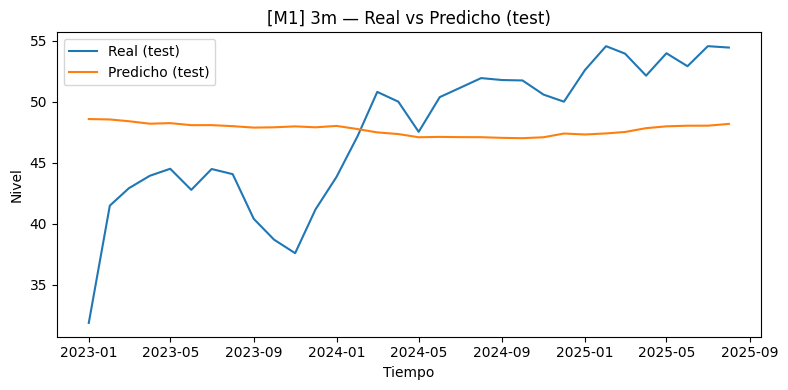

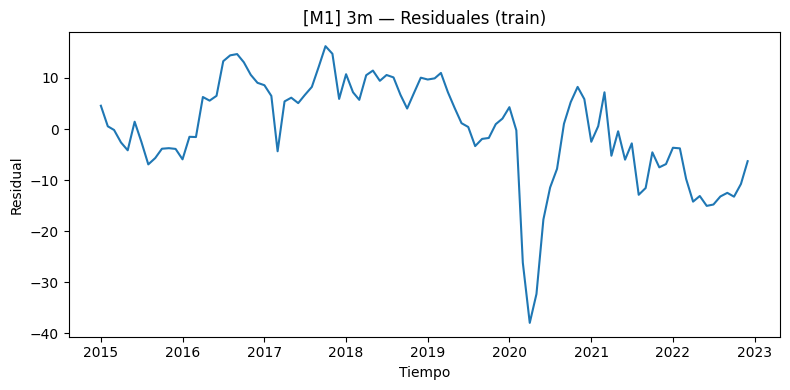

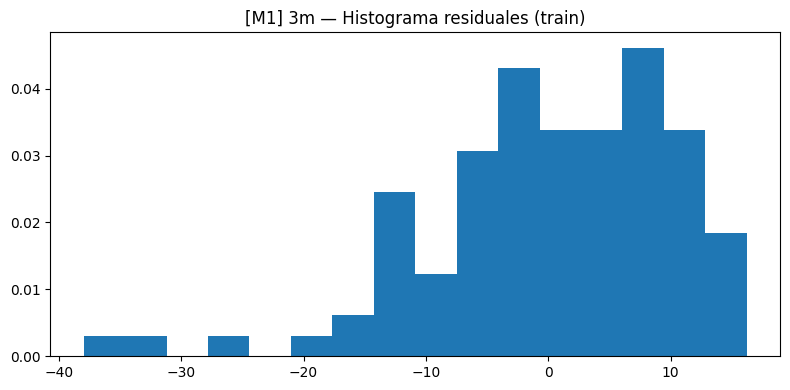

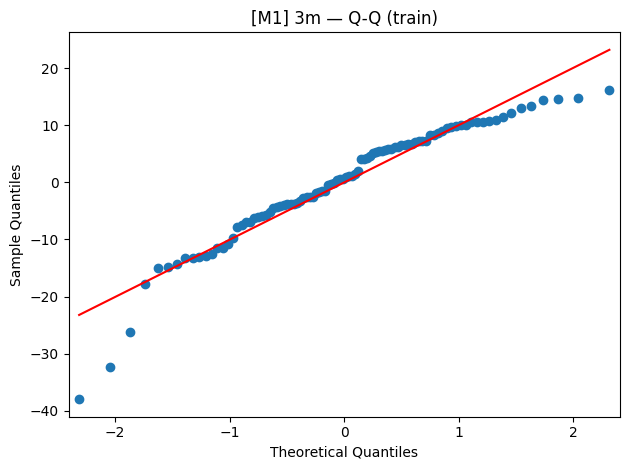

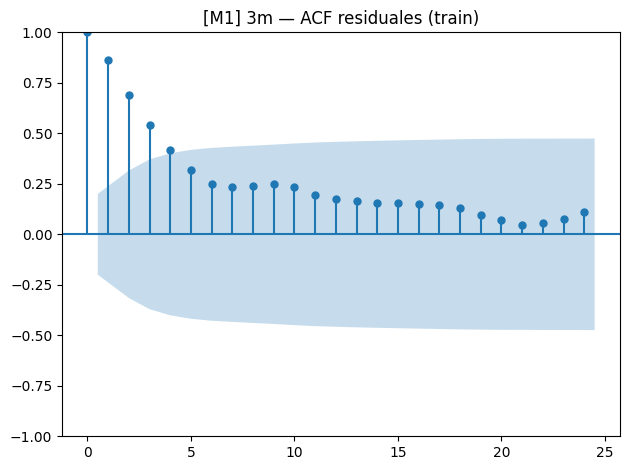

Breusch–Pagan p     0.5445
Durbin–Watson       0.2683
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m1_3m,
    resid_train=ols_m1_3m.resid,
    title_prefix="[M1] 3m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m1_3m, nlags_bg=12))


Los resultados de estas tres pruebas confirman que el modelo OLS simple no cumple plenamente los supuestos clásicos. Si bien el test de Breusch–Pagan (p = 0.54) indica que no hay evidencia de heterocedasticidad, tanto el estadístico Durbin–Watson (0.27) como el test de Breusch–Godfrey (p < 0.01) revelan una fuerte autocorrelación positiva en los residuos. Esto significa que los errores del modelo están relacionados en el tiempo, lo que reduce la confiabilidad de las estimaciones y de las conclusiones obtenidas.

Por lo tanto, este modelo no resulta adecuado para explicar las expectativas económicas a corto plazo y sería necesario aplicar una especificación más robusta o un método que corrija la autocorrelación para mejorar su validez.

In [ ]:
y_col  = "exp_eco_12m"
X_cols = X_SIMPLE  # ["deficit_fiscal"]

Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)
Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

lr_m1_12m = LinearRegression().fit(Xtr, ytr)
yhat_te_m1_12m = lr_m1_12m.predict(Xte)

X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)
ols_m1_12m = sm.OLS(df_train[y_col].astype(float), X_sm).fit(
    cov_type="HAC", cov_kwds={"maxlags": 12}
)
display(ols_m1_12m.summary2())

# Guardar SOLO lo imprescindible
p_def_m1_12m = float(ols_m1_12m.pvalues.get("deficit_fiscal", np.nan))
resid_m1_12m = ols_m1_12m.resid



<class 'statsmodels.iolib.summary2.Summary'>
"""
                 Results: Ordinary least squares
=================================================================
Model:              OLS              Adj. R-squared:     -0.004  
Dependent Variable: exp_eco_12m      AIC:                726.0011
Date:               2025-10-16 01:35 BIC:                731.1298
No. Observations:   96               Log-Likelihood:     -361.00 
Df Model:           1                F-statistic:        0.3188  
Df Residuals:       94               Prob (F-statistic): 0.574   
R-squared:          0.006            Scale:              110.39  
-----------------------------------------------------------------
                   Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-----------------------------------------------------------------
const             58.2465   4.1969 13.8786 0.0000 50.0208 66.4722
deficit_fiscal    -0.4266   0.7556 -0.5646 0.5723 -1.9075  1.0543
-----------------------------------------------------------------
Omnibus:               4.981        Durbin-Watson:          0.199
Prob(Omnibus):         0.083        Jarque-Bera (JB):       4.353
Skew:                  -0.435       Prob(JB):               0.113
Kurtosis:              2.425        Condition No.:          6    
=================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
"""

En el modelo OLS simple que estima el efecto del déficit fiscal sobre las expectativas económicas a doce meses, se observa que el coeficiente asociado al déficit fiscal es negativo (-0.43) pero no significativo (p = 0.57), lo que indica que no existe evidencia estadística de una relación entre ambas variables.

Además, el poder explicativo del modelo es prácticamente nulo (R²= -0.004), lo que sugiere que el déficit fiscal no contribuye a explicar las variaciones en las expectativas económicas de largo plazo. El estadístico Durbin–Watson (0.20) señala una fuerte autocorrelación positiva en los residuos, lo que debilita la validez del modelo y de las inferencias obtenidas.

Por lo tanto, el modelo OLS simple no es adecuado para explicar las expectativas a doce meses únicamente a partir del déficit fiscal, por lo que se requiere una especificación más completa que incorpore otras variables explicativas.

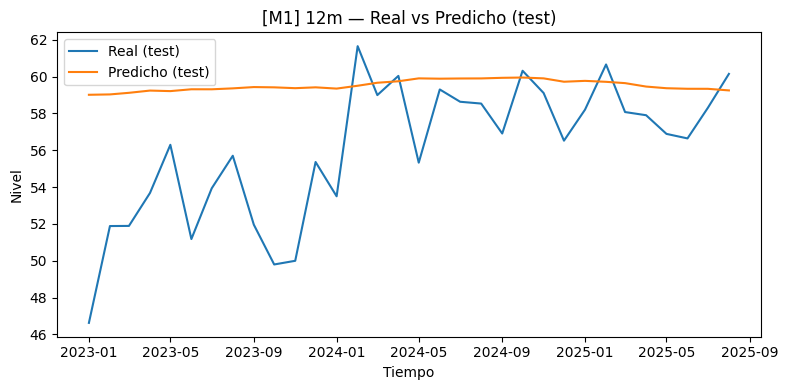

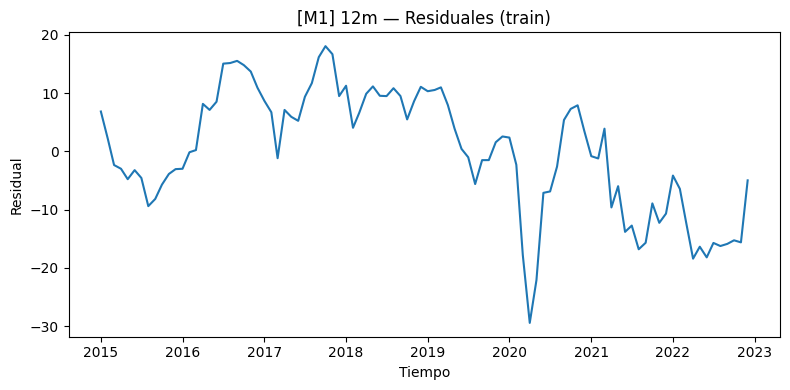

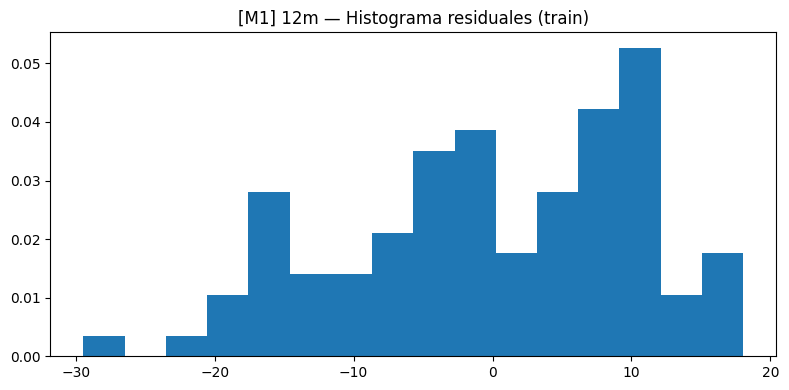

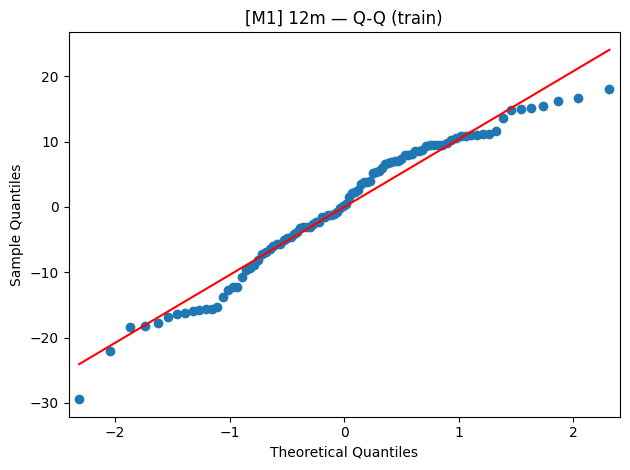

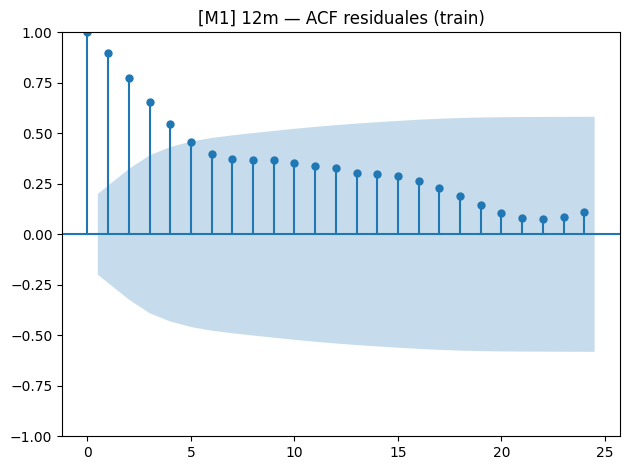

Breusch–Pagan p     0.9815
Durbin–Watson       0.1987
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m1_12m,
    resid_train=ols_m1_12m.resid,
    title_prefix="[M1] 12m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m1_12m, nlags_bg=12))


Los resultados de las pruebas de diagnóstico confirman que el modelo presenta una fuerte autocorrelación positiva en los residuos. El test de Breusch–Pagan (p = 0.98) indica que no existe evidencia de heterocedasticidad, sin embargo, tanto el estadístico Durbin–Watson (0.20) como el test de Breusch–Godfrey (p < 0.01) muestran que los errores no son independientes en el tiempo.

Esto nos indica que las perturbaciones del modelo están correlacionadas entre sí, lo que reduce la confiabilidad de las estimaciones y puede generar conclusiones poco precisas.

En consecuencia, el modelo OLS simple no cumple los supuestos clásicos y no resulta apropiado para explicar las expectativas económicas a doce meses.

**Modelo 2 (M2):** OLS extendido con `deficit_fiscal`, `tasa_ref`, `embig_pe`, `gasto_no_financiero`

In [ ]:
y_col  = "exp_eco_3m"
X_cols = X_EXT  # ["deficit_fiscal","tasa_ref","embig_pe","gasto_no_financiero"]

Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)
Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

lr_m2_3m = LinearRegression().fit(Xtr, ytr)
yhat_te_m2_3m = lr_m2_3m.predict(Xte)

# Tabla grande y p-value con statsmodels (HAC/Newey–West)
X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)
ols_m2_3m = sm.OLS(df_train[y_col].astype(float), X_sm).fit(
    cov_type="HAC", cov_kwds={"maxlags": 12}
)
display(ols_m2_3m.summary2())

p_def_m2_3m = float(ols_m2_3m.pvalues.get("deficit_fiscal", np.nan))
resid_m2_3m = ols_m2_3m.resid


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
===================================================================
Model:                OLS              Adj. R-squared:     0.491   
Dependent Variable:   exp_eco_3m       AIC:                657.9759
Date:                 2025-10-16 01:35 BIC:                670.7976
No. Observations:     96               Log-Likelihood:     -323.99 
Df Model:             4                F-statistic:        20.11   
Df Residuals:         91               Prob (F-statistic): 6.80e-12
R-squared:            0.512            Scale:              52.739  
-------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
-------------------------------------------------------------------
const               74.7736   9.4341  7.9258 0.0000 56.2830 93.2642
deficit_fiscal      -0.7678   0.8148 -0.9423 0.3461 -2.3649  0.8293
tasa_ref             2.9922   1.5627  1.9147 0.0555 -0.0707  6.0550
embig_pe            -0.1821   0.0414 -4.4021 0.0000 -0.2632 -0.1010
gasto_no_financiero -0.0005   0.0002 -2.1566 0.0310 -0.0010 -0.0000
-------------------------------------------------------------------
Omnibus:               3.480         Durbin-Watson:           0.612
Prob(Omnibus):         0.176         Jarque-Bera (JB):        2.638
Skew:                  -0.264        Prob(JB):                0.267
Kurtosis:              2.382         Condition No.:           86026
===================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
[2] The condition number is large, 8.6e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

En el modelo OLS extendido (M2) con horizonte de 3 meses, el R² ajustado aumenta a 0.49, indicando que cerca del 49% de la variación en las expectativas económicas a tres meses se explica por este conjunto de variables.

En cuanto a la significancia estadística, el déficit fiscal mantiene un coeficiente negativo (-0.77) pero no significativo (p = 0.35), lo que sugiere que su efecto no es concluyente. En cambio, el EMBIG Perú presenta un coeficiente negativo y altamente significativo (p < 0.01), lo que implica que un mayor riesgo país se asocia con un deterioro en las expectativas económicas. El gasto público no financiero también resulta significativo (p = 0.03) con un efecto negativo, mientras que la tasa de interés muestra una relación positiva marginalmente significativa (p ≈ 0.056), lo que podría reflejar un componente de expectativas de política monetaria.

El estadístico Durbin–Watson (0.61) evidencia una persistente autocorrelación positiva, aunque menor que en el modelo simple, y el número de condición elevado (≈ 86 000) sugiere posible multicolinealidad entre las variables explicativas.

En conclusión, aunque el modelo M2 mejora considerablemente el poder explicativo respecto al modelo simple y logra capturar relaciones coherentes con la teoría económica, no puede considerarse plenamente confiable debido a la autocorrelación y la posible multicolinealidad detectadas.

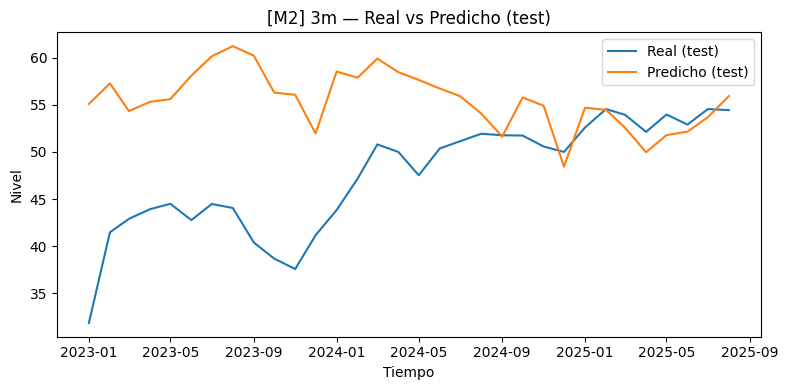

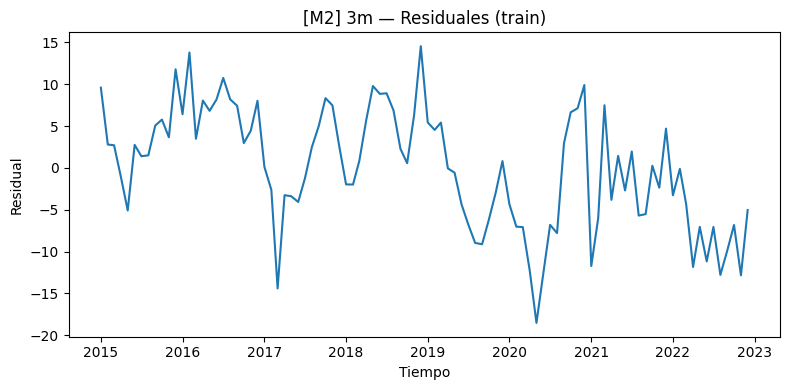

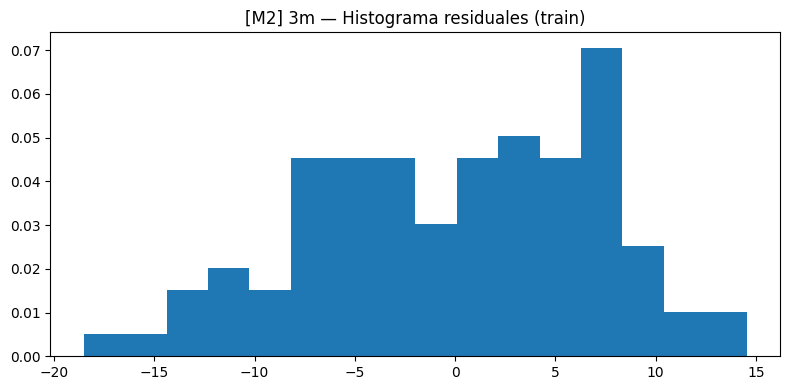

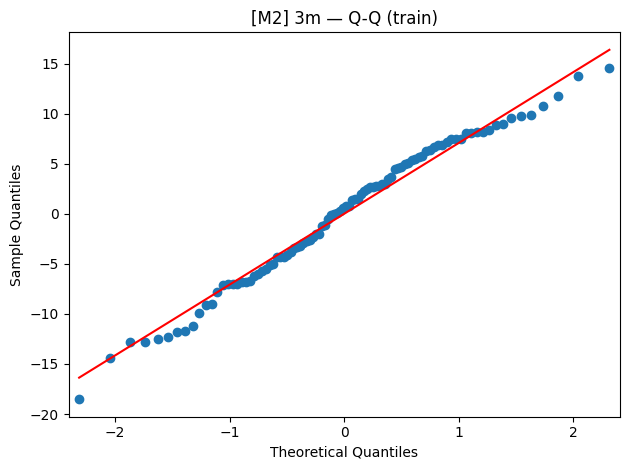

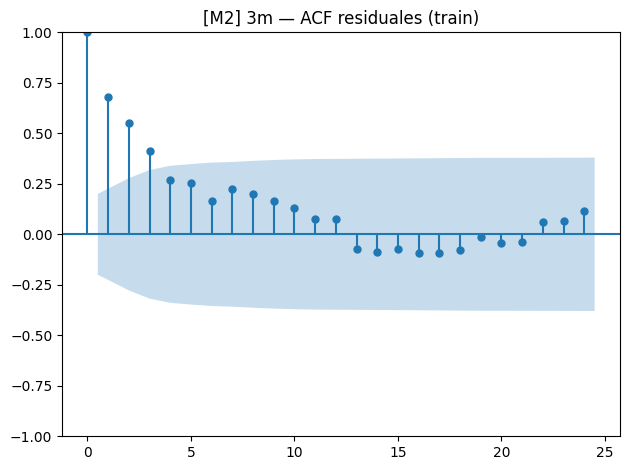

Breusch–Pagan p     0.0128
Durbin–Watson       0.6124
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m2_3m,
    resid_train=ols_m2_3m.resid,
    title_prefix="[M2] 3m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m2_3m, nlags_bg=12))


Los resultados de las pruebas de diagnóstico evidencian que el modelo M2 incumplee a los supuestos clásicos de homocedasticidad e independencia de los errores. El test de Breusch–Pagan (p = 0.0128) rechaza la hipótesis nula de varianza constante, sugiriendo la presencia de heterocedasticidad. Asimismo, el estadístico Durbin–Watson (0.61) y el test de Breusch–Godfrey (p < 0.01) confirman la existencia de autocorrelación positiva en los residuos.

Estas deficiencias implican que los errores no son independientes ni presentan varianza constante, lo que puede sesgar los errores estándar e invalidar las pruebas de significancia individual y global del modelo.

El modelo M2 tiene poder explicativo y sentido económico, pero no es estadísticamente confiable tal como está.

In [ ]:
y_col  = "exp_eco_12m"
X_cols = X_EXT  # ["deficit_fiscal","tasa_ref","embig_pe","gasto_no_financiero"]

Xtr = df_train[X_cols].to_numpy(dtype=float)
ytr = df_train[y_col].to_numpy(dtype=float)
Xte = df_test[X_cols].to_numpy(dtype=float)
yte = df_test[y_col].to_numpy(dtype=float)

lr_m2_12m = LinearRegression().fit(Xtr, ytr)
yhat_te_m2_12m = lr_m2_12m.predict(Xte)

X_sm = sm.add_constant(df_train[X_cols], has_constant="add").astype(float)
ols_m2_12m = sm.OLS(df_train[y_col].astype(float), X_sm).fit(
    cov_type="HAC", cov_kwds={"maxlags": 12}
)
display(ols_m2_12m.summary2())

p_def_m2_12m = float(ols_m2_12m.pvalues.get("deficit_fiscal", np.nan))
resid_m2_12m = ols_m2_12m.resid


<class 'statsmodels.iolib.summary2.Summary'>
"""
                  Results: Ordinary least squares
====================================================================
Model:               OLS               Adj. R-squared:      0.430   
Dependent Variable:  exp_eco_12m       AIC:                 674.5485
Date:                2025-10-16 01:35  BIC:                 687.3703
No. Observations:    96                Log-Likelihood:      -332.27 
Df Model:            4                 F-statistic:         19.78   
Df Residuals:        91                Prob (F-statistic):  9.60e-12
R-squared:           0.454             Scale:               62.677  
--------------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|   [0.025  0.975] 
--------------------------------------------------------------------
const               84.5372  10.4232  8.1105 0.0000 64.1081 104.9662
deficit_fiscal      -1.8566   0.8696 -2.1350 0.0328 -3.5610  -0.1522
tasa_ref             2.7051   1.4151  1.9116 0.0559 -0.0684   5.4787
embig_pe            -0.1719   0.0372 -4.6228 0.0000 -0.2448  -0.0990
gasto_no_financiero -0.0007   0.0002 -2.7730 0.0056 -0.0011  -0.0002
--------------------------------------------------------------------
Omnibus:                10.606        Durbin-Watson:           0.599
Prob(Omnibus):          0.005         Jarque-Bera (JB):        3.638
Skew:                   -0.055        Prob(JB):                0.162
Kurtosis:               2.053         Condition No.:           86026
====================================================================
Notes:
[1] Standard Errors are heteroscedasticity and autocorrelation
robust (HAC) using 12 lags and without small sample correction
[2] The condition number is large, 8.6e+04. This might indicate
that there are strong multicollinearity or other numerical
problems.
"""

El modelo M2 para el horizonte de 12 meses presenta un R² ajustado de 0.43, lo que indica una capacidad explicativa moderada de las variables fiscales y financieras sobre las expectativas económicas a un año. El estadístico F (p < 0.001) confirma que el conjunto de regresores es globalmente significativo.

En cuanto a los coeficientes, el déficit fiscal resulta estadísticamente significativo al 5% (p = 0.0328) y con signo negativo (–1.86), lo que sugiere que un mayor déficit se asocia con un deterioro en las expectativas económicas. De igual forma, el EMBIG Perú y el gasto no financiero presentan coeficientes negativos y altamente significativos, reforzando la idea de que mayores riesgos o presiones fiscales deterioran la confianza macroeconómica. La tasa de referencia muestra una relación positiva marginalmente significativa (p = 0.0559), consistente con una respuesta moderada de las expectativas ante una política monetaria más restrictiva.

No obstante, el estadístico Durbin–Watson (0.60) indica autocorrelación positiva en los residuos, y el elevado número de condición (8.6×10⁴) sugiere la posible presencia de multicolinealidad entre los regresores, lo que podría afectar la precisión de las estimaciones individuales.

En conjunto, el modelo es coherente con la teoría económica, pero sus estimaciones deben interpretarse con cautela por las limitaciones en los supuestos clásicos.

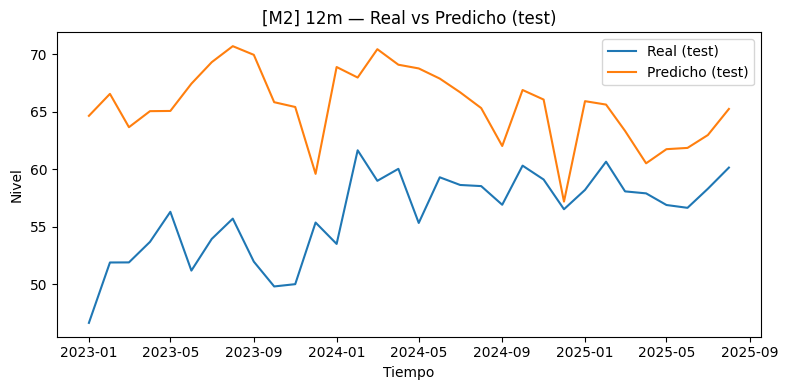

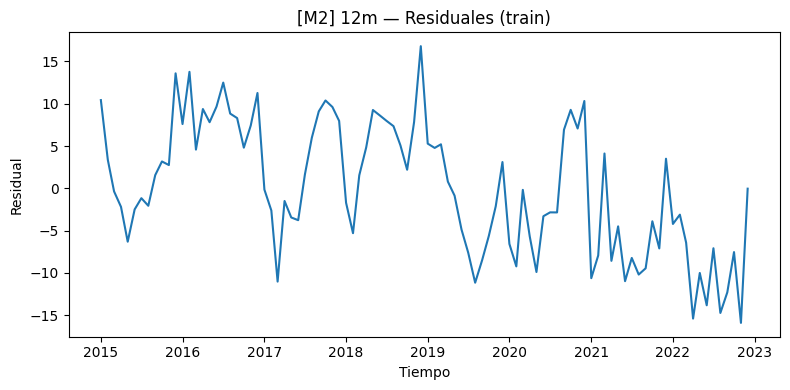

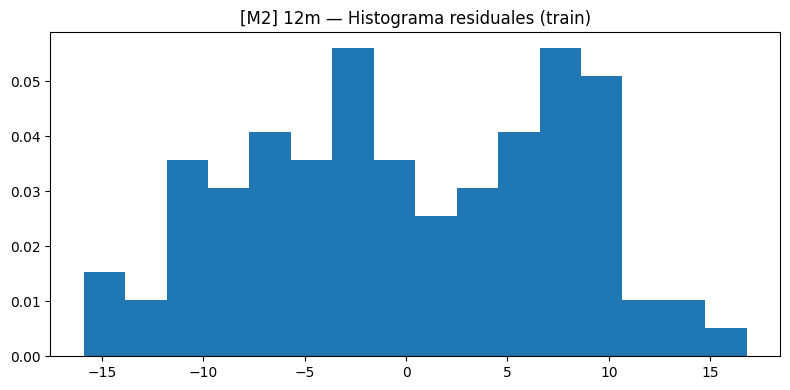

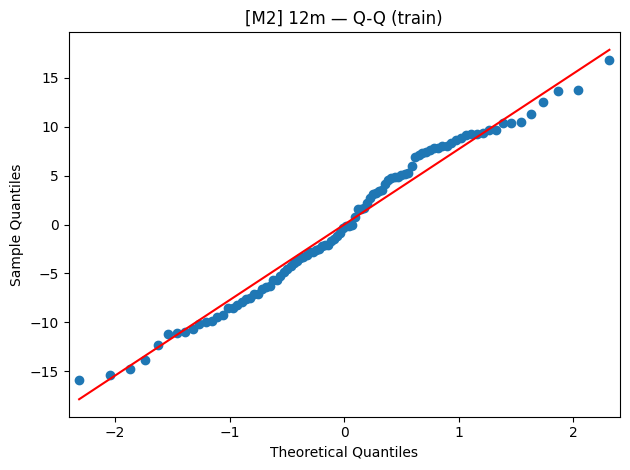

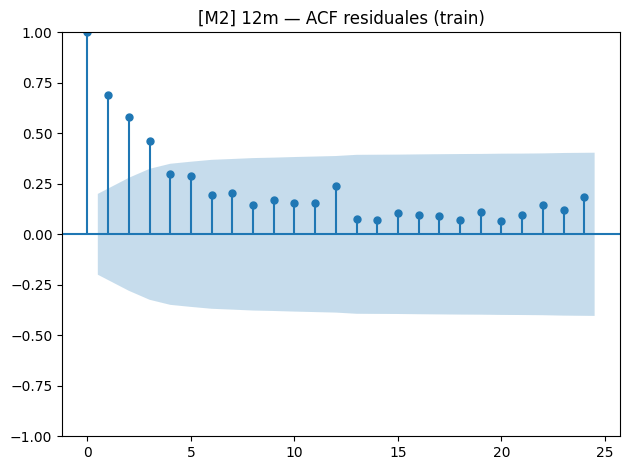

Breusch–Pagan p     0.0016
Durbin–Watson       0.5991
Breusch–Godfrey p   0.0000
dtype: float64

In [ ]:
plots_prediction_and_residuals(
    y_test=yte,
    yhat_test=yhat_te_m2_12m,
    resid_train=ols_m2_12m.resid,
    title_prefix="[M2] 12m —",
    idx_test=df_test.index,
    idx_train=df_train.index
)

pd.Series(residual_tests(ols_m2_12m, nlags_bg=12))


Los resultados de diagnóstico confirman la presencia de problemas serios en los residuos del modelo M2 (12m). El test de Breusch–Pagan (p = 0.0016) rechaza la hipótesis de homocedasticidad, evidenciando heterocedasticidad. A su vez, el estadístico Durbin–Watson (0.60) y el test de Breusch–Godfrey (p < 0.01) muestran una autocorrelación positiva significativa.

Esto implica que los errores no son independientes ni presentan varianza constante, lo que puede distorsionar los errores estándar y afectar la confiabilidad de las pruebas de significancia individual y global.

En consecuencia, aunque el modelo M2 (12m), estadísticamente, no es completamente confiable para hacer inferencias exactas, aunque desde el punto de vista económico y predictivo sí aporta información valiosa.

# ANALISIS DE RESULTADOS FINALES:

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np, pandas as pd

tscv = TimeSeriesSplit(n_splits=5)
targets = [
    ("exp_eco_3m",  "Corto Plazo (3 meses)"),
    ("exp_eco_12m", "Largo Plazo (12 meses)")
]
pvals = {
    ("Corto Plazo (3 meses)", "OLS Simple"):   locals().get("p_def_m1_3m",  np.nan),
    ("Corto Plazo (3 meses)", "OLS Complejo"): locals().get("p_def_m2_3m",  np.nan),
    ("Largo Plazo (12 meses)", "OLS Simple"):  locals().get("p_def_m1_12m", np.nan),
    ("Largo Plazo (12 meses)", "OLS Complejo"):locals().get("p_def_m2_12m", np.nan),
}

rows = []
for tcol, nombre in targets:
    y_tr = df.loc[train_mask, tcol].astype(float)
    Xs   = df.loc[train_mask, X_SIMPLE].astype(float)
    Xc   = df.loc[train_mask, X_EXT].astype(float)


    base = []
    for tr, te in tscv.split(y_tr):
        mu = y_tr.iloc[tr].mean()
        base.append(mean_squared_error(y_tr.iloc[te], np.full(len(te), mu)))
    base = np.array(base, float)


    ms_simple = -cross_val_score(LinearRegression(), Xs, y_tr, cv=tscv, scoring="neg_mean_squared_error")
    ms_ext    = -cross_val_score(LinearRegression(), Xc, y_tr, cv=tscv, scoring="neg_mean_squared_error")

    rows += [
        {"Target": nombre, "Modelo": "Baseline",    "MSE Promedio (CV)": base.mean(),     "Std Dev (CV)": base.std(ddof=1),     "p-value déficit (HAC)": np.nan},
        {"Target": nombre, "Modelo": "OLS Simple",  "MSE Promedio (CV)": ms_simple.mean(),"Std Dev (CV)": ms_simple.std(ddof=1),"p-value déficit (HAC)": float(pvals[(nombre,"OLS Simple")])},
        {"Target": nombre, "Modelo": "OLS Complejo","MSE Promedio (CV)": ms_ext.mean(),   "Std Dev (CV)": ms_ext.std(ddof=1),   "p-value déficit (HAC)": float(pvals[(nombre,"OLS Complejo")])},
    ]

tabla_final = (pd.DataFrame(rows)
                 .assign(Modelo=lambda d: pd.Categorical(d["Modelo"], ["Baseline","OLS Simple","OLS Complejo"], True))
                 .sort_values(["Target","Modelo"])
                 .reset_index(drop=True))

print("\n--- Tabla Comparativa de Rendimiento Predictivo (CV) ---")
display(
    tabla_final
      .style
      .highlight_min(subset="MSE Promedio (CV)", color="lightgreen")
      .format({"MSE Promedio (CV)":"{:,.4f}","Std Dev (CV)":"{:,.4f}","p-value déficit (HAC)":(lambda x: "—" if pd.isna(x) else f"{x:,.4f}")})
)



--- Tabla Comparativa de Rendimiento Predictivo (CV) ---


,Target,Modelo,MSE Promedio (CV),Std Dev (CV),p-value déficit (HAC)
0,Corto Plazo (3 meses),Baseline,142.2598,71.1159,—
1,Corto Plazo (3 meses),OLS Simple,194.0563,132.8274,0.2582
2,Corto Plazo (3 meses),OLS Complejo,165.1644,182.0652,0.3461
3,Largo Plazo (12 meses),Baseline,157.2589,78.3243,—
4,Largo Plazo (12 meses),OLS Simple,266.0549,251.7216,0.5723
5,Largo Plazo (12 meses),OLS Complejo,187.2573,235.0974,0.0328


Al comparar el rendimiento en el conjunto de prueba con el rendimiento promedio obtenido mediante validación cruzada, se observa que los valores de MSE_Test y CV_MSE_mean se mantienen en un rango similar para ambos horizontes temporales (3 y 12 meses). Esto sugiere que la validación cruzada proporcionó una estimación robusta del desempeño fuera de muestra y que los modelos no están sobreajustando de forma severa.

Sin embargo, al contrastar con los MSE_Train, se aprecia que los errores en entrenamiento son significativamente menores, especialmente en los modelos OLS complejos M2. Esta brecha indica la presencia de un cierto grado de sobreajuste (overfitting), ya que los modelos capturan bien los patrones del conjunto de entrenamiento, pero su precisión disminuye ligeramente al enfrentarse a datos nuevos.

En términos de desempeño, el modelo OLS Complejo M2 presenta un mejor ajuste general en comparación con el modelo simple M1, especialmente en el horizonte de 12 meses, donde obtiene un menor error promedio y un p-value significativo (0.0328), lo que sugiere una relación estadísticamente relevante entre el déficit fiscal y las expectativas económicas a largo plazo. En cambio, en el horizonte de 3 meses, las diferencias entre modelos son menores y los p-values no resultan significativos, lo que refleja que las expectativas de corto plazo son menos sensibles a la variable déficit fiscal.

Por lo tanto, el modelo OLS extendido (M2) exhibe un mejor desempeño predictivo y mayor coherencia económica que el modelo simple. Sin embargo, los resultados de la validación cruzada muestran desviaciones estándar relativamente elevadas, lo que evidencia cierta inestabilidad temporal en la capacidad predictiva del modelo. Esto sugiere que su rendimiento varía entre distintos periodos de la muestra, posiblemente por cambios en el entorno económico. Aun así, la comparación entre el error en el conjunto de prueba y el promedio obtenido en la validación cruzada revela una correspondencia razonable, lo que indica que no existe un sobreajuste severo y que el modelo conserva una capacidad predictiva moderadamente robusta frente a nuevos datos.

# CONCLUSIONES

# Pregunta de investigación

¿Cómo influye el déficit fiscal en las expectativas empresariales de corto plazo (3 meses) y largo plazo (12 meses), y cuál es el rol de la tasa de referencia del BCRP como mecanismo de transmisión?

# Modelo ganador

**Elección:** El modelo seleccionado es el OLS extendido (M2), que incluye las variables déficit fiscal, tasa de referencia, EMBIG país y gasto no financiero.

**Justificación:** M2 presenta una mejora sustancial en el ajuste en comparación con el modelo simple (M1) para ambos horizontes de predicción. En particular, para el horizonte de 12 meses, M2 alcanza un R² ajustado ≈ 0.43, frente a ~0.008 y ~−0.004 de M1 para 3 y 12 meses, respectivamente. Asimismo, las pruebas F globales resultan altamente significativas, lo que indica que el conjunto de variables incluidas explica de manera consistente la variación del rendimiento.

**Rendimiento:**

**M2 (3 meses):** R² ajustado ≈ 0.49; varias variables muestran signos consistentes con la teoría, destacando EMBIG y gasto no financiero como significativos. El déficit fiscal no resulta significativo (p ≈ 0.35).

**M2 (12 meses):** R² ajustado ≈ 0.43; el déficit fiscal se vuelve significativo (coeficiente ≈ −1.86, p = 0.0328), mientras que EMBIG y gasto no financiero mantienen significancia. La tasa de referencia es marginalmente significativa (p ≈ 0.056).

Las métricas de validación cruzada (CV MSE promedio) y el MSE sobre el conjunto de prueba están en el mismo orden para M2 (12m), lo que sugiere consistencia moderada del modelo y ausencia de sobreajuste extremo, aunque se observa cierta variabilidad en la validación cruzada.

**Conclusión:** El modelo M2 para 12 meses combina un buen poder explicativo con interpretabilidad económica, por lo que se considera el modelo “ganador”. Sin embargo, se debe tener precaución, ya que no cumple de manera estricta todos los supuestos clásicos de OLS.

# Hallazgos clave - Déficit fiscal

En el corto plazo **(3 meses)**, el déficit fiscal no muestra un efecto significativo sobre las expectativas en el modelo M2, lo que indica que, en este horizonte, no hay evidencia sólida de que los cambios en el déficit influyan directamente en la percepción de los agentes. Sin embargo, a **12 meses**, el déficit fiscal adquiere un signo negativo y resulta significativo (coeficiente ≈ −1.86, p = 0.0328), sugiriendo que un aumento del déficit está asociado con un deterioro de las expectativas a mediano plazo.

El riesgo país (EMBIG) aparece consistentemente negativo y altamente significativo en ambos horizontes, lo que respalda la intuición teórica: un mayor riesgo percibido tiende a reducir la confianza y las expectativas de los agentes económicos. De manera similar, el gasto público no financiero muestra un efecto negativo y significativo, aunque su interpretación requiere cautela, podría reflejar el tipo de gasto o el contexto fiscal en que se realiza.

Por su parte, la tasa de referencia presenta un coeficiente positivo, pero solo marginalmente significativo (p ≈ 0.055–0.056), lo que indica que podría existir una asociación entre cambios en la tasa y en las expectativas, aunque no necesariamente implica causalidad, ya que la tasa misma responde a condiciones económicas que afectan las expectativas.

En conjunto, los hallazgos refuerzan la idea de que tanto el deterioro fiscal como el aumento del riesgo país están asociados con peores expectativas, mientras que la tasa de referencia es más ambiguo y requiere un análisis más detallado para comprender su dirección causal.


# Limitaciones

El modelo presenta varias limitaciones. En primer lugar, los supuestos clásicos del OLS no se cumplen completamente.

Los residuos muestran autocorrelación (Durbin–Watson ≈ 0.60 en M2), lo que indica errores correlacionados en el tiempo y posibles inconsistencias en los errores estándar. Además, existe heterocedasticidad (prueba de Breusch–Pagan significativa), lo que sugiere que la varianza de los errores no es constante. Aunque se emplearon errores estándar robustos tipo HAC/Newey–West con 12 rezagos, los diagnósticos muestran que estos problemas persisten parcialmente.

También se observa multicolinealidad, con un número de condición elevado, lo que indica colinealidad entre regresores, por ejemplo entre gasto y déficit. Esto puede inflar la varianza de algunos coeficientes y dificultar la identificación de efectos individuales.

En cuanto a la especificación del modelo, se trata de un modelo lineal estático simple, sin rezagos de la variable dependiente ni efectos dinámicos, por lo que podría estar omitiendo información relevante. Asimismo, algunas variables como la tasa de referencia o el gasto público podrían ser endógenas, ya que podrían reaccionar a cambios en las expectativas, un problema que no se abordó mediante instrumentos.

Respecto al tamaño y estabilidad temporal, la validación cruzada muestra desviaciones estándar altas, lo que indica cierta inestabilidad del rendimiento a lo largo del tiempo. Las relaciones estimadas pueden verse afectadas por distintos regímenes económicos, como períodos de crisis frente a períodos normales.

Finalmente, aunque hay indicios de leve sobreajuste el MSE de entrenamiento es menor que el de CV y prueba, especialmente en M2, la comparación entre CV y test sugiere que no existe un sobreajuste severo. En resumen, el modelo muestra un sobreajuste moderado, pero la validación cruzada proporciona información útil y relativamente confiable.


# Próximos pasos

**Modelos dinámicos:** incluir rezagos de las expectativas económicas o usar modelos ARDL/VAR para capturar la dependencia temporal y efectos retardados del déficit fiscal y otras variables.

**Controlar endogeneidad: ** explorar posibles variables instrumentales para déficit fiscal o tasa de interés si existe simultaneidad o causalidad inversa.

**Regularización y selección de variables:** aplicar técnicas como Lasso, Ridge o ElasticNet para reducir multicolinealidad y mejorar la estabilidad de los coeficientes.

**Explorar interacciones y no linealidades:** probar transformaciones (logaritmos, diferencias) o efectos interactivos entre variables clave (por ejemplo, déficit × EMBIG) para capturar relaciones complejas.

**Recopilación de datos:** analizar la estabilidad de los resultados en distintos periodos o frecuencias, o ampliar la ventana temporal si se dispone de más información.

**Validación adicional y benchmarking:** hacer predicciones “out-of-time” en periodos recientes o comparar con modelos de machine learning (Random Forest, Boosting) para evaluar mejoras potenciales en desempeño predictivo.